In [1]:
import pandas as pd
import numpy as np


In [2]:
# Read the CSV file
file_path = '2-url_video_features.csv'
df = pd.read_csv(file_path)

# Check the data
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())


Shape: (661, 2939)
Columns: ['url', 'title', 'label', 'video_1', 'video_2', 'video_3', 'video_4', 'video_5', 'video_6', 'video_7', 'video_8', 'video_9', 'video_10', 'video_11', 'video_12', 'video_13', 'video_14', 'video_15', 'video_16', 'video_17', 'video_18', 'video_19', 'video_20', 'video_21', 'video_22', 'video_23', 'video_24', 'video_25', 'video_26', 'video_27', 'video_28', 'video_29', 'video_30', 'video_31', 'video_32', 'video_33', 'video_34', 'video_35', 'video_36', 'video_37', 'video_38', 'video_39', 'video_40', 'video_41', 'video_42', 'video_43', 'video_44', 'video_45', 'video_46', 'video_47', 'video_48', 'video_49', 'video_50', 'video_51', 'video_52', 'video_53', 'video_54', 'video_55', 'video_56', 'video_57', 'video_58', 'video_59', 'video_60', 'video_61', 'video_62', 'video_63', 'video_64', 'video_65', 'video_66', 'video_67', 'video_68', 'video_69', 'video_70', 'video_71', 'video_72', 'video_73', 'video_74', 'video_75', 'video_76', 'video_77', 'video_78', 'video_79', 'video_

In [3]:
df

,url,title,label,video_1,video_2,video_3,video_4,video_5,video_6,video_7,...,video_2927,video_2928,video_2929,video_2930,video_2931,video_2932,video_2933,video_2934,video_2935,video_2936
0,https://youtube.com/shorts/qsEH_66Tz8o?si=HqLM...,THAT KNOCKOUT PUNCH💥📈,Violence,-0.032548,0.014445,-0.027356,-0.139634,-0.010487,0.009161,-0.119355,...,2.661120,2.158230,0.206279,1.455674,1.261710,1.868976,0,0,0,0
1,https://youtube.com/shorts/MQIEwDx9ctY?si=hlUr...,छावा अभी जिंदा है 😳🔥Vicky Kaushal #ytshorts #c...,Violence,0.036135,-0.084180,-0.025128,-0.582166,0.086977,-0.043535,-0.143290,...,2.792867,2.090225,4.270677,6.470384,2.743291,1.652323,0,0,0,0
2,https://youtube.com/shorts/09sL1SlQ8hY?si=mzUD...,Father And Son 💀,Violence,0.096812,-0.083584,0.015581,-0.389490,0.066124,0.046624,-0.196986,...,2.649454,2.040925,10.313511,13.222808,2.483910,2.136208,0,0,0,0
3,https://youtube.com/shorts/VprRifC7J9U?si=0GF9...,Aura Farming by mahavatar Narsimha ✨🥶 #shorts ...,Violence,-0.012442,-0.073659,0.010728,-0.761370,0.121815,-0.060735,-0.145556,...,4.271146,1.865784,3.598204,6.515498,2.416809,1.763376,0,0,0,0
4,https://youtube.com/shorts/okdcWqJLL8k?si=p5VW...,Rajasaab 🔥 x Daaha bgm☠️,Violence,0.016041,-0.080761,0.091861,0.287160,0.069726,-0.031996,-0.254120,...,3.776830,1.755931,11.669321,9.450757,3.387313,1.593998,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,https://youtube.com/shorts/UHVRuJLmpeg?si=cQq6...,Riddhima Sharma vs Chandrika Dixit: Vada Pav G...,Toxic,0.095640,-0.048740,0.031021,-0.009370,0.007534,0.019777,-0.024845,...,3.046462,1.730259,3.443501,8.373497,2.637572,1.858460,0,0,0,0
657,https://youtube.com/shorts/fjDUJNfHpaM?si=1XFr...,Riddhima Sharma ने kanika Sharma को बताया ब्रा...,Toxic,0.060665,-0.052571,0.013550,-0.383128,0.055966,0.026235,-0.060435,...,3.373204,1.721059,2.556825,3.690795,3.484075,1.424418,0,0,0,0
658,https://youtube.com/shorts/DQ-py4VFjDI?si=efP5...,Riddhima sharma on rock #hindu #mamtabanerjee ...,Toxic,0.026920,-0.005022,0.008538,-0.643661,0.031580,-0.009880,-0.078976,...,2.617630,1.967442,4.985781,10.819516,2.774281,2.013609,0,0,0,0
659,https://youtube.com/shorts/2b_XYeNIOQ0?si=x-C-...,A Haryana Girl Came to CJP Protest Jantar Mant...,Toxic,0.171954,-0.094323,-0.025662,-0.224180,-0.023671,0.051307,-0.014332,...,3.108141,2.255394,8.036651,11.621861,2.832173,1.763708,0,0,0,0


In [4]:
class_labels = df["label"].unique().tolist()
print(class_labels)

['Violence', 'Hateful', 'Toxic', 'Explicit', 'Normal']


In [5]:
# Separate features, filename, and class ; first column is filename, last column is class
X = df.drop(columns=["url","title", "label"])
y = df["label"]

Lebel encoders

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 3, 3, 3, 0, 0, 2,
       2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

Class to numeric mapping

In [7]:
# Visualize class to  numeric mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nClass to Numeric Mapping:")
for class_name, numeric in class_mapping.items():
    print(f"  {class_name} -> {numeric}")


Class to Numeric Mapping:
  Explicit -> 0
  Hateful -> 1
  Normal -> 2
  Toxic -> 3
  Violence -> 4


# Step 3: Split into train and test data (80% train, 20% test)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=44,
    stratify=y_encoded  # Maintains class balance
)

In [9]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [10]:
# slect best model
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="saga", random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128, 64, 32),max_iter=300,random_state=42)}

# Check if scaling is needed

In [11]:
needs_scaling = (X.mean().abs() > 0.01).any() or ((X.std() - 1).abs() > 0.01).any()

In [12]:
print(f"Needs Scaling: {needs_scaling}")
print(f"Max |Mean|: {X.mean().abs().max():.4f}")
print(f"Max |Std - 1|: {(X.std() - 1).abs().max():.4f}")

Needs Scaling: True
Max |Mean|: 11.4409
Max |Std - 1|: 10.8558


In [13]:
if needs_scaling:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
else:
    X_train_scaled = X_train
    X_test_scaled = X_test

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [15]:
for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

Show best model

In [16]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



Training Logistic Regression...
Accuracy: 0.6391


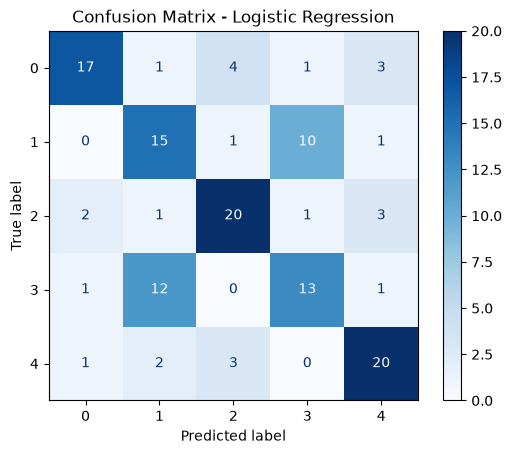


Training Naive Bayes...
Accuracy: 0.6391


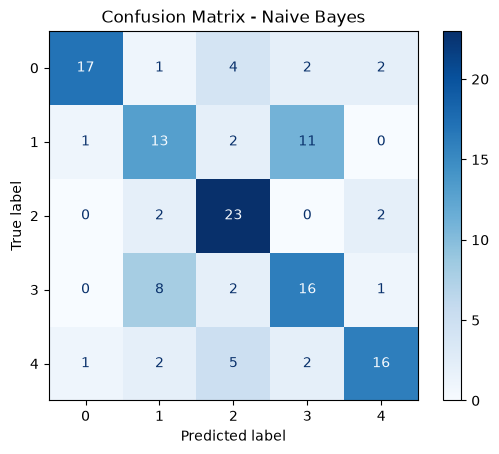


Training KNN...
Accuracy: 0.3985


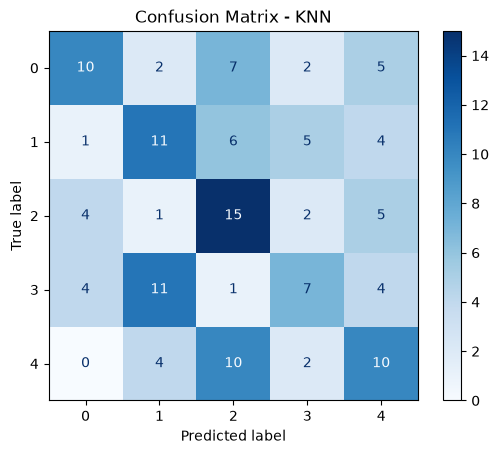


Training Decision Tree...
Accuracy: 0.5338


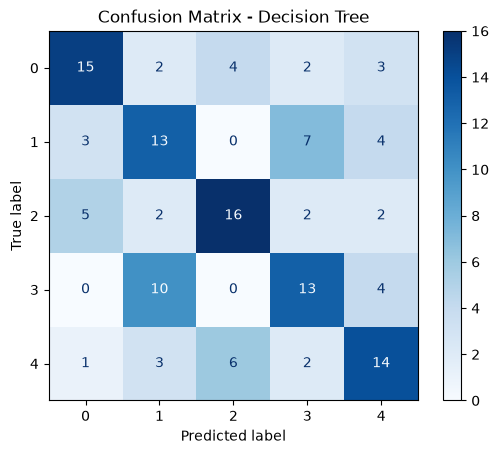


Training Random Forest...
Accuracy: 0.6541


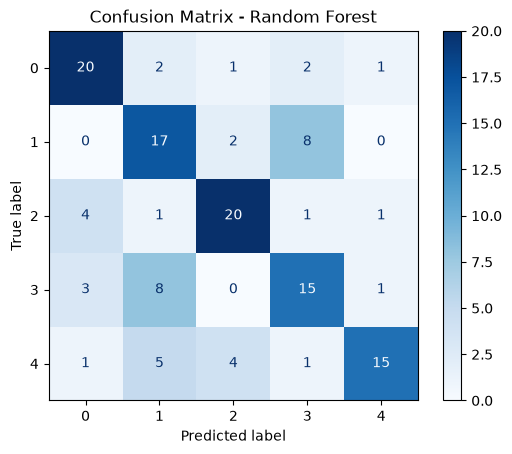


Training AdaBoost...
Accuracy: 0.5639


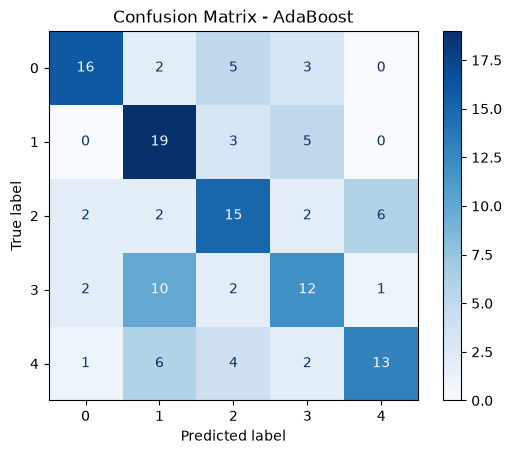


Training Gradient Boosting...
Accuracy: 0.6617


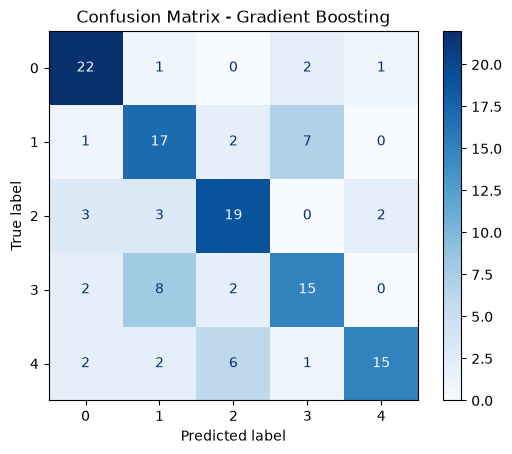


Training XGBoost...
Accuracy: 0.6391


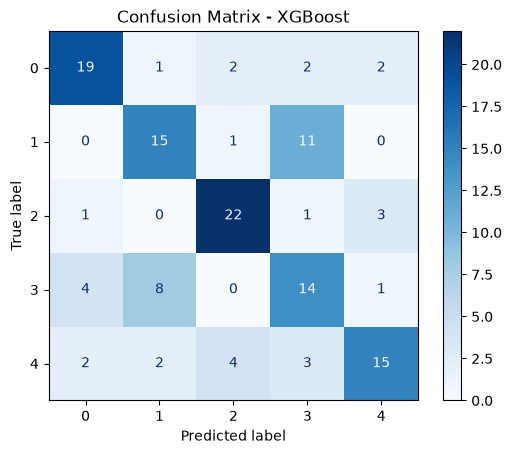


Training SVM...
Accuracy: 0.4135


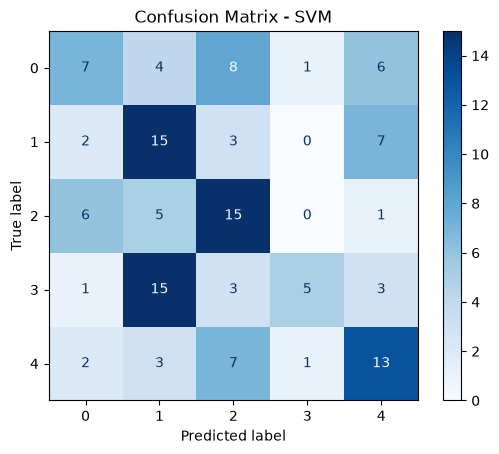


Training Neural Network...
Accuracy: 0.6541


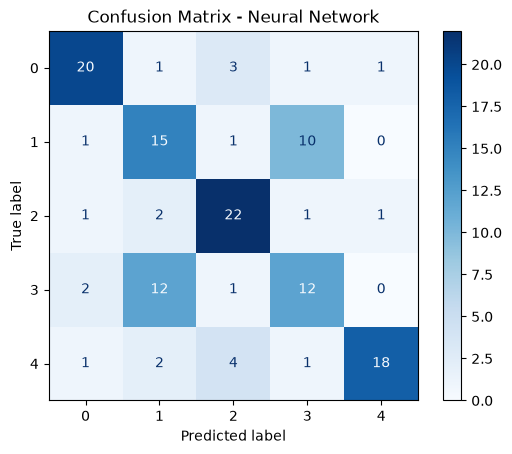

In [17]:
# Compare all models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"Accuracy: {accuracy:.4f}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d')

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [18]:
best_model= max(results, key=results.get)
print(f"\n{'='*50}")
print("BEST MODEL:")
best_model_name = max(results, key=results.get)
print(f"{best_model} with accuracy: {results[best_model]:.4f}")


BEST MODEL:
Gradient Boosting with accuracy: 0.6617


In [19]:
results_df1 = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df1)

                 Model  Accuracy
0  Logistic Regression  0.639098
1          Naive Bayes  0.639098
2                  KNN  0.398496
3        Decision Tree  0.533835
4        Random Forest  0.654135
5             AdaBoost  0.563910
6    Gradient Boosting  0.661654
7              XGBoost  0.639098
8                  SVM  0.413534
9       Neural Network  0.654135


K-fold stratefication

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        estimator = Pipeline([("scaler", StandardScaler()), ("model", model)])
    else:
        estimator = model

    scores = cross_validate(
        estimator,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores['test_accuracy'].mean(),
        "Precision": scores['test_precision'].mean(),
        "Recall": scores['test_recall'].mean(),
        "F1-Score": scores['test_f1'].mean()
    })

results_df2 = pd.DataFrame(results)
print(results_df2)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.677759   0.684116  0.677759  0.677203
1          Naive Bayes  0.630852   0.634911  0.630852  0.629678
2                  KNN  0.580920   0.632473  0.580920  0.572501
3        Decision Tree  0.515858   0.517274  0.515858  0.512886
4        Random Forest  0.655032   0.660063  0.655032  0.653501
5             AdaBoost  0.596099   0.614732  0.596099  0.598192
6    Gradient Boosting  0.644467   0.646840  0.644467  0.643598
7              XGBoost  0.677753   0.679023  0.677753  0.674147
8                  SVM  0.661107   0.669567  0.661107  0.661116
9       Neural Network  0.671692   0.672732  0.671692  0.669405
